In [3]:
import numpy as np
from flight_optimizer import *
import itertools

In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
def find_min_delta(solution: FlightSolution):
    min_gap = float('inf')
    for aircraft, flights in solution.assignment.items():
        for f1, f2 in itertools.combinations(flights, 2):
            if f2.arrival_time < f1.arrival_time:
                f1, f2 = f2, f1

            min_gap = min(min_gap, f2.departure_time - f1.arrival_time)

    return min_gap

In [6]:
def problem_path(d: float, p: int, h: int, test_index: int,max_d: int):
    return f"./data/With maintenance constraints/d={max_d}/DataCplex_density={d}_p={p}_h={h}_test_{test_index}.dat"


def solution_path(d: float, p: int, h: int, test_index: int, max_d: int):
    if max_d == 5:
        return f"./data/With maintenance constraints/d={max_d}/Optimal_Solution_density={d}_p={p}_h={h}_test_{test_index}_dmax_{max_d}.txt"
    else:
        return f"./data/With maintenance constraints/d={max_d}/Optimal_Solution_density={d}_p={p}_h={h}_test_{test_index}.txt"

In [5]:
# D = [0.5, 0.7, 1]
# P = [10, 20, 30, 40]
# H = [7, 15, 21, 30]

# print('d\t| p\t| h\t| i\t| min_gap')
# for density, planes, horizon, index in itertools.product(D, P, H, range(10)):
#     try:
#         problem = FlightProblem.from_file(problem_path(density, planes, horizon, index))
#         solution = FlightSolution.from_file(solution_path(density, planes, horizon, index), problem)
#         min_gap = find_min_delta(solution)
#         print(f'{density}\t| {planes}\t| {horizon}\t| {index}\t| {min_gap}')
#     except Exception as e:
#         print(f'{density}\t| {planes}\t| {horizon}\t| {index}\t| {type(e)}')


In [11]:
instance = (1,10,15,1, 4)

In [7]:
instances = [
    (0.5, 10, 30, 8),
    (0.5, 20, 21, 1),
    (0.5, 20, 30, 3),
    (0.5, 20, 30, 5),
    (0.5, 30, 7, 1),
    (0.5, 30, 7, 5),
    (0.5, 30, 7, 7),
    (0.5, 30, 7, 8),
    (0.5, 30, 15, 2),
]

In [16]:
reporter = Reporter()

In [12]:
problem = FlightProblemMaintenance.from_file(problem_path(*instance), instance[4])


In [34]:
reduced_solver = ReducedFlowSolver()
solution_found_1 = reduced_solver.solve_maintenance(problem)

number of decision variables : 5730
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: AMD Ryzen 7 8845HS w/ Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 6003 rows, 5730 columns and 205370 nonzeros
Model fingerprint: 0x97b61984
Variable types: 0 continuous, 5730 integer (5730 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+00]
  Objective range  [4e+03, 2e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+00]
Presolve removed 2325 rows and 1453 columns
Presolve time: 0.28s
Presolved: 3678 rows, 4277 columns, 126874 nonzeros
Variable types: 0 continuous, 4277 integer (4277 binary)

Root relaxation: objective 3.481932e+06, 16667 iterations, 1.83 seconds (3.25 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd 

In [14]:
solution = FlightSolutionMaintenance.from_file(solution_path(*instance), problem)

In [40]:
(solution_found_1.cost - solution.cost) / solution.cost *100

np.float64(-1.6749749452664557)

In [15]:
_ = reporter.plot_solution([solution])

AttributeError: module 'flight_optimizer.reporter' has no attribute 'plot_solution'

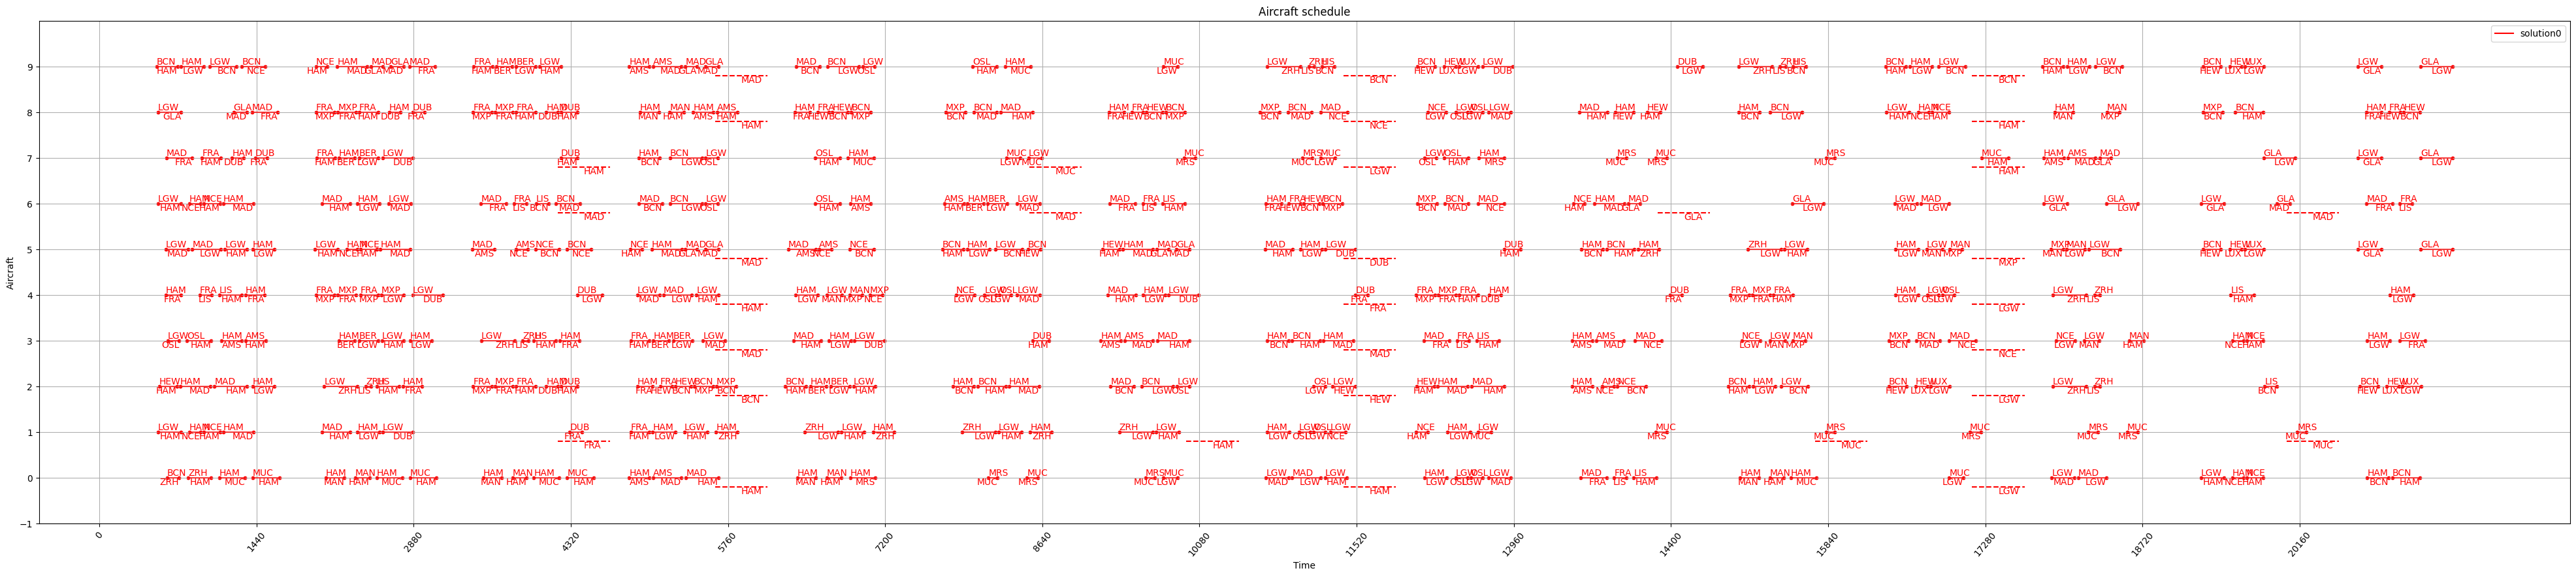

In [17]:
_ = reporter.plot_solution([solution])

In [12]:
solution.maintenances

{0: [(3, Airport(id=0, name='BCN')),
  (7, Airport(id=5, name='NCE')),
  (11, Airport(id=2, name='LGW'))],
 1: [(3, Airport(id=7, name='DUB')),
  (7, Airport(id=7, name='DUB')),
  (11, Airport(id=10, name='MXP'))],
 2: [(3, Airport(id=0, name='BCN')),
  (7, Airport(id=1, name='HAM')),
  (11, Airport(id=10, name='MXP'))],
 3: [(3, Airport(id=1, name='HAM')),
  (7, Airport(id=10, name='MXP')),
  (11, Airport(id=1, name='HAM'))],
 4: [(3, Airport(id=16, name='MUC')),
  (7, Airport(id=1, name='HAM')),
  (11, Airport(id=1, name='HAM'))],
 5: [(3, Airport(id=2, name='LGW')),
  (7, Airport(id=2, name='LGW')),
  (11, Airport(id=2, name='LGW'))],
 6: [(1, Airport(id=3, name='MAD')),
  (5, Airport(id=16, name='MUC')),
  (9, Airport(id=2, name='LGW')),
  (13, Airport(id=1, name='HAM'))],
 7: [(3, Airport(id=1, name='HAM')),
  (7, Airport(id=5, name='NCE')),
  (11, Airport(id=6, name='GLA'))],
 8: [(3, Airport(id=7, name='DUB')),
  (7, Airport(id=1, name='HAM')),
  (11, Airport(id=1, name='HAM'))]

In [27]:
print([solution_found_1.get_maintenance_interval(day) for day, _ in solution_found_1.maintenances[0]])


[(5640, 6120), (11400, 11880), (17160, 17640)]


In [26]:
print(sorted([(flight.departure_time, flight.arrival_time)for flight in solution_found_1.assignment[0]]))

[(555, 750), (800, 940), (940, 1145), (1210, 1445), (2040, 2325), (2365, 2595), (2595, 2900), (4380, 4640), (4945, 5265), (5270, 5465), (5465, 5700), (6385, 6520), (6560, 6815), (6860, 7125), (8310, 8470), (8515, 8665), (10045, 10320), (10715, 10915), (11195, 11340), (12120, 12265), (12265, 12465), (12470, 12785), (13485, 13705), (13715, 13890), (14115, 14245), (15035, 15235), (15305, 15465), (15500, 15765), (16950, 17110), (17890, 18125), (18130, 18420), (19330, 19565), (19570, 19860), (20785, 21105), (21200, 21410)]


In [16]:
solution_found_1.maintenances

{0: [(3, Airport(id=3, name='MAD')),
  (7, Airport(id=3, name='MAD')),
  (11, Airport(id=3, name='MAD'))],
 1: [(2, Airport(id=3, name='MAD')),
  (10, Airport(id=3, name='MAD')),
  (6, Airport(id=6, name='GLA'))],
 2: [(2, Airport(id=16, name='MUC')),
  (6, Airport(id=16, name='MUC')),
  (10, Airport(id=16, name='MUC'))],
 3: [(2, Airport(id=3, name='MAD')),
  (6, Airport(id=16, name='MUC')),
  (10, Airport(id=16, name='MUC'))],
 4: [(6, Airport(id=3, name='MAD')),
  (10, Airport(id=3, name='MAD')),
  (2, Airport(id=16, name='MUC'))],
 5: [(2, Airport(id=3, name='MAD')),
  (6, Airport(id=3, name='MAD')),
  (10, Airport(id=3, name='MAD'))],
 6: [(2, Airport(id=3, name='MAD')),
  (6, Airport(id=3, name='MAD')),
  (10, Airport(id=3, name='MAD'))],
 7: [(11, Airport(id=3, name='MAD')),
  (7, Airport(id=16, name='MUC')),
  (3, Airport(id=6, name='GLA'))],
 8: [(6, Airport(id=3, name='MAD')),
  (2, Airport(id=16, name='MUC')),
  (10, Airport(id=16, name='MUC'))],
 9: [(3, Airport(id=3, name=